# Real-Time British Sign Language (BSL) Translation System
## For Enhanced Communication - Prototype v1.0

---

**Project Goal:** Build a working prototype that recognises selected BSL signs from raw image/video data and converts them into English text labels in **real time**.

**Scope (v1.0):**
- BSL alphabets (A-Z)
- Common greetings (Hello, Thank you, Yes, No) *if available in the dataset*
- Isolated sign recognition **only**

> **Important Disclaimer:** Full BSL translation requires movement, facial expression, body posture, and sentence-level context. This prototype is limited to **isolated static sign recognition** from single images. It does **not** translate BSL grammar or continuous signing.

**Dataset Used:** [BSL Fingerspelling Dataset (Kaggle)](https://www.kaggle.com/datasets/alifsathar/bsl-fingerspelling-dataset)
- 20,910 images across 26 classes (A-Z)
- ~804 images per class
- ~192 MB total

**Technical Stack:**
Python, PyTorch, Torchvision, OpenCV, MediaPipe, Pandas, NumPy, Scikit-learn, Matplotlib

**Environment:** Google Colab (CUDA-enabled GPU, ~12GB RAM, ~15GB VRAM)

## Section 1: Setup and Installation

Install all required packages and verify CUDA availability.

In [1]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

packages = [
    "torch",
    "torchvision",
    "opencv-python-headless",
    "mediapipe",
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "tqdm",
    "Pillow",
    "efficientnet-pytorch",
    "kaggle",
]

print("Installing packages...")
for pkg in packages:
    install(pkg)
print("All packages installed!")

Installing packages...
All packages installed!


In [2]:
import os, sys, json, csv, time, copy, random, shutil, hashlib, warnings
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision
from torchvision import transforms, models

import mediapipe as mp

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

print("All libraries imported!")

All libraries imported!


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"CUDA available! GPU: {gpu_name}, VRAM: {gpu_mem:.1f} GB")
else:
    print("CUDA not available, using CPU.")
print(f"Device: {device}")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(f"Random seed: {SEED}, Reproducibility enabled")

CUDA available! GPU: Tesla T4, VRAM: 14.6 GB
Device: cuda
Random seed: 42, Reproducibility enabled


## Section 2: Project Folder Structure

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alifsathar/bsl-fingerspelling-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bsl-fingerspelling-dataset' dataset.
Path to dataset files: /kaggle/input/bsl-fingerspelling-dataset


In [5]:
# Mount Google Drive for persistence (uncomment to use)
# from google.colab import drive
# drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/BSL_Project")
# For Drive: PROJECT_ROOT = Path("/content/drive/MyDrive/BSL_Project")

DIRS = {
    "raw_data": PROJECT_ROOT / "raw_data",
    "raw_images": PROJECT_ROOT / "raw_data" / "images",
    "raw_videos": PROJECT_ROOT / "raw_data" / "videos",
    "processed_data": PROJECT_ROOT / "processed_data",
    "train": Path(path) / "train",
    "val": PROJECT_ROOT / "processed_data" / "val",
    "test": Path(path) / "test",
    "hand_crops": PROJECT_ROOT / "processed_data" / "hand_crops",
    "rejected": PROJECT_ROOT / "raw_data" / "rejected",
    "annotations": PROJECT_ROOT / "annotations",
    "models": PROJECT_ROOT / "models",
    "results": PROJECT_ROOT / "results",
    "deployment": PROJECT_ROOT / "deployment",
}

for name, dir_path in DIRS.items():
    dir_path.mkdir(parents=True, exist_ok=True)

print("Project structure created:")
for name, dir_path in sorted(DIRS.items(), key=lambda x: str(x[1])):
    status = "OK" if dir_path.exists() else "MISSING"
    print(f"  [{status}] {dir_path}")

Project structure created:
  [OK] /content/BSL_Project/annotations
  [OK] /content/BSL_Project/deployment
  [OK] /content/BSL_Project/models
  [OK] /content/BSL_Project/processed_data
  [OK] /content/BSL_Project/processed_data/hand_crops
  [OK] /content/BSL_Project/processed_data/val
  [OK] /content/BSL_Project/raw_data
  [OK] /content/BSL_Project/raw_data/images
  [OK] /content/BSL_Project/raw_data/rejected
  [OK] /content/BSL_Project/raw_data/videos
  [OK] /content/BSL_Project/results
  [OK] /kaggle/input/bsl-fingerspelling-dataset/test
  [OK] /kaggle/input/bsl-fingerspelling-dataset/train


## Section 3: Dataset Download and Loading

Download the BSL Fingerspelling Dataset from Kaggle. You need a Kaggle API token from https://www.kaggle.com/settings

In [6]:
# The dataset has been downloaded via kagglehub in a previous step.
# We will use the paths already defined in our DIRS dictionary.

RAW_TRAIN_DIR = DIRS["train"]
RAW_TEST_DIR = DIRS["test"]

for name, path in [("Train", RAW_TRAIN_DIR), ("Test", RAW_TEST_DIR)]:
    if path.exists():
        print(f"Using existing {name} dataset at: {path}")
        # List a few files to verify
        sample_files = list(path.glob("*/*"))[:3]
        if sample_files:
            print(f"Found {name} data files. Ready to proceed.")
    else:
        print(f"Warning: {name} dataset directory not found at {path}")

# We will primarily use RAW_TRAIN_DIR for initial discovery
RAW_IMAGES_DIR = RAW_TRAIN_DIR

Using existing Train dataset at: /kaggle/input/bsl-fingerspelling-dataset/train
Found Train data files. Ready to proceed.
Using existing Test dataset at: /kaggle/input/bsl-fingerspelling-dataset/test
Found Test data files. Ready to proceed.


In [7]:
def discover_classes(data_dir):
    data_path = Path(data_dir)
    classes = sorted([d.name for d in data_path.iterdir() if d.is_dir()])
    class_counts = {}
    total = 0
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}
    for cls in classes:
        imgs = [f for f in (data_path / cls).iterdir() if f.suffix.lower() in valid_ext]
        class_counts[cls] = len(imgs)
        total += len(imgs)
    return classes, class_counts, total

classes, class_counts, total_images = discover_classes(RAW_IMAGES_DIR)
print(f"Classes: {len(classes)}, Total images: {total_images}")
print("\nClass distribution:")
for cls, cnt in class_counts.items():
    bar = "#" * (cnt // 10)
    print(f"  {cls:<5}: {cnt:>5}  {bar}")

Classes: 7, Total images: 20674

Class distribution:
  A    :  3002  ############################################################################################################################################################################################################################################################################################################
  B    :  3002  ############################################################################################################################################################################################################################################################################################################
  C    :  3002  #########################################################################################################################################################################################################################################################################################################

## Section 4: Class Mapping and File Standardization

In [8]:
def create_class_mapping(classes, output_path):
    class_mapping = {name: idx for idx, name in enumerate(classes)}
    reverse_mapping = {idx: name for name, idx in class_mapping.items()}
    mapping_data = {
        "class_mapping": class_mapping,
        "reverse_mapping": reverse_mapping,
        "num_classes": len(classes),
        "classes": classes,
        "created_at": datetime.now().isoformat(),
    }
    out = Path(output_path) / "class_mapping.json"
    with open(out, "w", encoding="utf-8") as f:
        json.dump(mapping_data, f, indent=2, ensure_ascii=False)
    print(f"Class mapping saved: {out}")
    return class_mapping, reverse_mapping, mapping_data

class_mapping, reverse_mapping, mapping_data = create_class_mapping(classes, DIRS["annotations"])
print("\nMapping:")
for name, idx in class_mapping.items():
    print(f"  {name}: {idx}")

Class mapping saved: /content/BSL_Project/annotations/class_mapping.json

Mapping:
  A: 0
  B: 1
  C: 2
  D: 3
  E: 4
  F: 5
  G: 6


In [10]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

def standardize_filename(filepath, label_name, index):
    ext = filepath.suffix.lower()
    if ext not in VALID_EXTENSIONS:
        return None
    return f"{label_name}_user01_{index:04d}{ext}"

def standardize_dataset(data_dir, class_mapping):
    """
    NOTE: This function is skipped because /kaggle/input is read-only.
    Standardization will be handled during the 'Organize Dataset' step
    where files are copied to a writable directory.
    """
    print("Skipping in-place standardization: Source directory is read-only.")
    print("Filenames will be managed during the organization/copying phase.")

# standardize_dataset(RAW_IMAGES_DIR, class_mapping)

## Section 5: Raw Data Validation

In [13]:
import hashlib
from pathlib import Path
import pandas as pd
import shutil
from PIL import Image
import cv2
import numpy as np
from tqdm import tqdm
import os

def compute_file_hash(filepath, block_size=65536):
    h = hashlib.md5()
    try:
        with open(filepath, "rb") as f:
            for block in iter(lambda: f.read(block_size), b""):
                h.update(block)
        return h.hexdigest()
    except Exception:
        return None

def validate_image(filepath):
    path = Path(filepath)

    # Check file exists and get stats
    if not path.exists():
        return False, "File does not exist"

    try:
        stat_info = path.stat()
    except OSError:
        return False, "Cannot access file"

    if stat_info.st_size == 0:
        return False, "Empty file"

    if stat_info.st_size < 1024:  # Less than 1KB
        return False, "File too small"

    # Validate with PIL
    try:
        with Image.open(filepath) as img:
            # Don't use verify() method as it doesn't always work correctly
            # Instead, try to get basic properties
            img_format = img.format
            img_size = img.size
            img_mode = img.mode

            # Basic checks
            if img_size[0] < 10 or img_size[1] < 10:
                return False, f"Image too small: {img_size}"

            # Try to convert to RGB to ensure it's a valid image
            if img.mode in ('RGBA', 'LA', 'P'):
                img = img.convert('RGB')
            elif img.mode != 'RGB':
                img = img.convert('RGB')

    except Exception as e:
        return False, f"PIL error: {str(e)[:80]}"

    # Validate with OpenCV
    try:
        img_cv = cv2.imread(str(filepath))
        if img_cv is None:
            return False, "OpenCV could not read"

        height, width = img_cv.shape[:2]
        if width < 10 or height < 10:
            return False, f"OpenCV: Image too small: ({width}, {height})"

    except Exception as e:
        return False, f"OpenCV error: {str(e)[:80]}"

    return True, "OK"

def validate_dataset(data_dir, rejected_dir=None):
    data_path = Path(data_dir)

    # Only create rejected directory if specified and we want to move files
    if rejected_dir:
        rejected_path = Path(rejected_dir)
        rejected_path.mkdir(parents=True, exist_ok=True)
    else:
        rejected_path = None

    results = []
    seen_hashes = {}
    total = 0
    valid = 0
    rejected = 0

    all_images = []
    for cls_dir in sorted(data_path.iterdir()):
        if cls_dir.is_dir():
            for f in cls_dir.iterdir():
                if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif']:  # Common image extensions
                    all_images.append(f)

    print(f"Validating {len(all_images)} images...")

    for filepath in tqdm(all_images, desc="Validating"):
        total += 1
        label = filepath.parent.name

        # Compute file hash
        fh = compute_file_hash(filepath)

        # Check for duplicates
        if fh and fh in seen_hashes:
            results.append({
                "image_path": str(filepath),
                "label": label,
                "status": "rejected",
                "reason": f"Duplicate of {seen_hashes[fh]}"
            })
            rejected += 1
            continue  # Skip moving since input dir is read-only

        if fh:
            seen_hashes[fh] = filepath.name

        # Validate the image
        try:
            ok, reason = validate_image(filepath)
        except Exception as e:
            ok = False
            reason = f"Unexpected error during validation: {str(e)}"

        if ok:
            results.append({
                "image_path": str(filepath),
                "label": label,
                "status": "valid",
                "reason": "OK"
            })
            valid += 1
        else:
            results.append({
                "image_path": str(filepath),
                "label": label,
                "status": "rejected",
                "reason": reason
            })
            rejected += 1

    # Create results DataFrame and save
    results_df = pd.DataFrame(results)

    # Only save to annotations if DIRS is defined, otherwise save to current directory
    try:
        results_df.to_csv(DIRS["annotations"] / "validation_log.csv", index=False)
    except:
        results_df.to_csv("validation_log.csv", index=False)

    print(f"Validation complete: Valid: {valid}, Rejected: {rejected}, Total: {total}")

    # Print summary
    rejected_by_reason = results_df[results_df['status'] == 'rejected']['reason'].value_counts()
    if len(rejected_by_reason) > 0:
        print("\nRejected by reason:")
        for reason, count in rejected_by_reason.items():
            print(f"  {reason}: {count}")

    return results_df

# Define common image extensions if not already defined
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

# Run validation (note: we don't specify a rejected_dir since input is read-only)
validation_df = validate_dataset(RAW_IMAGES_DIR)

Validating 20674 images...


Validating: 100%|██████████| 20674/20674 [01:06<00:00, 310.88it/s]


Validation complete: Valid: 18428, Rejected: 2246, Total: 20674

Rejected by reason:
  Duplicate of F138.jpg: 1
  Duplicate of A603 flip.jpg: 1
  Duplicate of A628.jpg: 1
  Duplicate of A148.jpg: 1
  Duplicate of A167.jpg: 1
  Duplicate of A800.jpg: 1
  Duplicate of F219.jpg: 1
  Duplicate of F128 flip.jpg: 1
  Duplicate of F92 flip.jpg: 1
  Duplicate of F142 flip.jpg: 1
  Duplicate of F61 flip.jpg: 1
  Duplicate of F177.jpg: 1
  Duplicate of F294 flip.jpg: 1
  Duplicate of F143 flip.jpg: 1
  Duplicate of F86 flip.jpg: 1
  Duplicate of F52.jpg: 1
  Duplicate of F96.jpg: 1
  Duplicate of F33 flip.jpg: 1
  Duplicate of F252 flip.jpg: 1
  Duplicate of F83 flip.jpg: 1
  Duplicate of F221.jpg: 1
  Duplicate of F157 flip.jpg: 1
  Duplicate of F217 flip.jpg: 1
  Duplicate of F73 flip.jpg: 1
  Duplicate of F67 flip.jpg: 1
  Duplicate of F282.jpg: 1
  Duplicate of F193 flip.jpg: 1
  Duplicate of F118.jpg: 1
  Duplicate of F93 flip.jpg: 1
  Duplicate of F99 flip.jpg: 1
  Duplicate of F276 flip.j

## Section 6: Video Frame Extraction

If the dataset contains video files, extract frames using OpenCV VideoCapture. The BSL Fingerspelling Dataset is image-only, but this section handles video data for extensibility.

In [16]:
RAW_VIDEOS_DIR = DIRS["raw_videos"]
VIDEO_FRAMES_DIR = PROJECT_ROOT / "raw_data" / "video_frames"
VIDEO_FRAMES_DIR.mkdir(parents=True, exist_ok=True)

def extract_frames_from_videos(videos_dir, output_dir, frame_interval=5, max_frames=50):
    vp = Path(videos_dir); op = Path(output_dir); op.mkdir(parents=True, exist_ok=True)
    vid_ext = {".mp4", ".avi", ".mov", ".mkv", ".wmv", ".flv", ".webm"}
    vids = [f for f in vp.iterdir() if f.suffix.lower() in vid_ext]
    if not vids:
        print("No video files found. Skipping frame extraction.")
        return []
    log = []
    print(f"Found {len(vids)} video(s)")
    for vf in tqdm(vids, desc="Extracting"):
        label = vf.parent.name if vf.parent.name != str(vp) else vf.stem.split("_")[0]
        label_dir = op / label; label_dir.mkdir(parents=True, exist_ok=True)
        cap = cv2.VideoCapture(str(vf))
        if not cap.isOpened():
            print(f"Cannot open: {vf.name}"); continue
        fc = 0; extracted = 0
        while extracted < max_frames:
            ret, frame = cap.read()
            if not ret: break
            if fc % frame_interval == 0:
                fname = f"{label}_{vf.stem}_{extracted:04d}.jpg"
                cv2.imwrite(str(label_dir / fname), frame)
                log.append({"video": str(vf), "frame": fname, "label": label})
                extracted += 1
            fc += 1
        cap.release()
    if log:
        pd.DataFrame(log).to_csv(DIRS["annotations"] / "video_extraction_log.csv", index=False)
        print(f"Extracted {len(log)} frames")
    return log

video_log = extract_frames_from_videos(RAW_VIDEOS_DIR, VIDEO_FRAMES_DIR)

No video files found. Skipping frame extraction.


## Section 7: Manual Label Annotation

In [17]:
def generate_annotations(train_dir, test_dir, class_mapping, output_path):
    annotations = []
    for data_dir, split_label in [(train_dir, "train"), (test_dir, "test")]:
        data_path = Path(data_dir)
        all_imgs = []
        for cls_dir in sorted(data_path.iterdir()):
            if cls_dir.is_dir():
                for f in sorted(cls_dir.iterdir()):
                    if f.suffix.lower() in VALID_EXTENSIONS:
                        all_imgs.append(f)

        print(f"Generating annotations for {len(all_imgs)} images in {split_label}...")
        for fp in tqdm(all_imgs, desc=f"Annotating {split_label}"):
            label_name = fp.parent.name
            label_id = class_mapping.get(label_name, -1)
            parts = fp.stem.split("_")
            user_id = next((p for p in parts if p.startswith("user")), "unknown")
            annotations.append({
                "image_path": str(fp), "label_name": label_name,
                "label_id": label_id, "user_id": user_id,
                "split": split_label, "quality_status": "pending", "notes": "",
            })

    df = pd.DataFrame(annotations)
    df.to_csv(output_path, index=False)
    print(f"\nTotal annotations saved: {output_path} ({len(df)} entries)")
    return df

annotations_df = generate_annotations(RAW_TRAIN_DIR, RAW_TEST_DIR, class_mapping, DIRS["annotations"] / "annotations.csv")
print("\nPreview:")
print(annotations_df.head(5).to_string())

Generating annotations for 20674 images in train...


Annotating train: 100%|██████████| 20674/20674 [00:00<00:00, 281334.89it/s]


Generating annotations for 236 images in test...


Annotating test: 100%|██████████| 236/236 [00:00<00:00, 148783.37it/s]



Total annotations saved: /content/BSL_Project/annotations/annotations.csv (20910 entries)

Preview:
                                                      image_path label_name  label_id  user_id  split quality_status notes
0   /kaggle/input/bsl-fingerspelling-dataset/train/A/A0 flip.jpg          A         0  unknown  train        pending      
1        /kaggle/input/bsl-fingerspelling-dataset/train/A/A0.jpg          A         0  unknown  train        pending      
2   /kaggle/input/bsl-fingerspelling-dataset/train/A/A1 flip.jpg          A         0  unknown  train        pending      
3        /kaggle/input/bsl-fingerspelling-dataset/train/A/A1.jpg          A         0  unknown  train        pending      
4  /kaggle/input/bsl-fingerspelling-dataset/train/A/A10 flip.jpg          A         0  unknown  train        pending      


## Section 8: MediaPipe Hand Annotation

Use MediaPipe Hands to detect hand regions, extract bounding boxes and landmarks, and create cropped hand images.

In [18]:
import os
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 1. Download the Hand Landmarker model file
model_path = 'hand_landmarker.task'
if not os.path.exists(model_path):
    print("Downloading Hand Landmarker model...")
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, model_path)

# 2. Initialize the Hand Landmarker using the Tasks API
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)
hands_detector = vision.HandLandmarker.create_from_options(options)

print(f"MediaPipe Tasks HandLandmarker initialized successfully using {model_path}")

MediaPipe Tasks HandLandmarker initialized successfully using hand_landmarker.task


In [19]:
HAND_CROPS_DIR = DIRS["hand_crops"]

def process_image_mediapipe(image_path, detector, crop_dir):
    p = Path(image_path)
    result = {"image_path": str(p), "hand_detected": False, "num_hands": 0,
              "x_min": "", "y_min": "", "x_max": "", "y_max": "",
              "landmark_points": "", "crop_path": "", "review_flag": ""}

    img_bgr = cv2.imread(str(p))
    if img_bgr is None:
        result["review_flag"] = "unreadable_image"; return result

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # Convert to MediaPipe Image object for Tasks API
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

    # Detect landmarks
    detection_result = detector.detect(mp_image)

    if detection_result.hand_landmarks:
        result["hand_detected"] = True
        result["num_hands"] = len(detection_result.hand_landmarks)

        # Use first detected hand
        hl = detection_result.hand_landmarks[0]
        lm_list, xc, yc = [], [], []

        for lm in hl:
            xc.append(lm.x * w); yc.append(lm.y * h)
            lm_list.append([round(lm.x * w, 2), round(lm.y * h, 2)])

        x1 = max(0, int(min(xc)) - 20); y1 = max(0, int(min(yc)) - 20)
        x2 = min(w, int(max(xc)) + 20); y2 = min(h, int(max(yc)) + 20)

        if (x2 - x1) < 30 or (y2 - y1) < 30:
            result["review_flag"] = "bounding_box_too_small"
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
            x1 = max(0, cx - 50); x2 = min(w, cx + 50)
            y1 = max(0, cy - 50); y2 = min(h, cy + 50)

        result.update({"x_min": x1, "y_min": y1, "x_max": x2, "y_max": y2,
                       "landmark_points": json.dumps(lm_list)})

        crop = img_rgb[y1:y2, x1:x2]
        label = p.parent.name
        cdir = Path(crop_dir) / label; cdir.mkdir(parents=True, exist_ok=True)
        cpath = cdir / f"crop_{p.stem}.jpg"
        cv2.imwrite(str(cpath), cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
        result["crop_path"] = str(cpath)

        if result["num_hands"] > 1:
            result["review_flag"] = ("multiple_hands" if not result["review_flag"] else result["review_flag"] + ",multiple_hands")
    else:
        result["review_flag"] = "no_hand_detected"
    return result

def annotate_all_images(ann_df, detector, crop_dir):
    print(f"Processing {len(ann_df)} images with MediaPipe Tasks API...")
    results = []; stats = Counter()
    # Processing a sample subset for speed in this prototype step if needed, or the whole set
    for _, row in tqdm(ann_df.iterrows(), total=len(ann_df), desc="MediaPipe"):
        r = process_image_mediapipe(row["image_path"], detector, crop_dir)
        r["label_name"] = row["label_name"]; r["label_id"] = row["label_id"]; r["user_id"] = row["user_id"]
        results.append(r)
        stats["hand_detected" if r["hand_detected"] else "no_hand"] += 1
        if r["review_flag"]: stats["needs_review"] += 1

    df = pd.DataFrame(results)
    df.to_csv(DIRS["annotations"] / "hand_annotations.csv", index=False)
    print(f"Done. Hand detected: {stats['hand_detected']}, No hand: {stats['no_hand']}, Needs review: {stats['needs_review']}")
    return df

print("Beginning hand detection processing...")
hand_annotations_df = annotate_all_images(annotations_df, hands_detector, HAND_CROPS_DIR)

Beginning hand detection processing...
Processing 20910 images with MediaPipe Tasks API...


MediaPipe: 100%|██████████| 20910/20910 [11:26<00:00, 30.44it/s]


Done. Hand detected: 12422, No hand: 8488, Needs review: 11862


## Section 9: Manual Review of Automatic Annotations

In [20]:
def review_annotations(hand_df):
    flagged = hand_df[hand_df["review_flag"] != ""].copy()
    if len(flagged) == 0:
        print("No images flagged for review!"); return flagged
    print(f"{len(flagged)} images flagged:")
    for flag_type in ["no_hand_detected", "bounding_box_too_small", "multiple_hands", "unreadable_image"]:
        subset = flagged[flagged["review_flag"].str.contains(flag_type, na=False)]
        if len(subset) > 0:
            print(f"  {flag_type}: {len(subset)}")
            for _, r in subset.head(2).iterrows():
                print(f"    - {Path(r['image_path']).name} ({r['label_name']})")
    flagged.to_csv(DIRS["annotations"] / "review_report.csv", index=False)
    return flagged

review_df = review_annotations(hand_annotations_df)

11862 images flagged:
  no_hand_detected: 8488
    - B108 flip.jpg (B)
    - B1208 flip.jpg (B)
  multiple_hands: 3374
    - A1055.jpg (A)
    - A1058 flip.jpg (A)


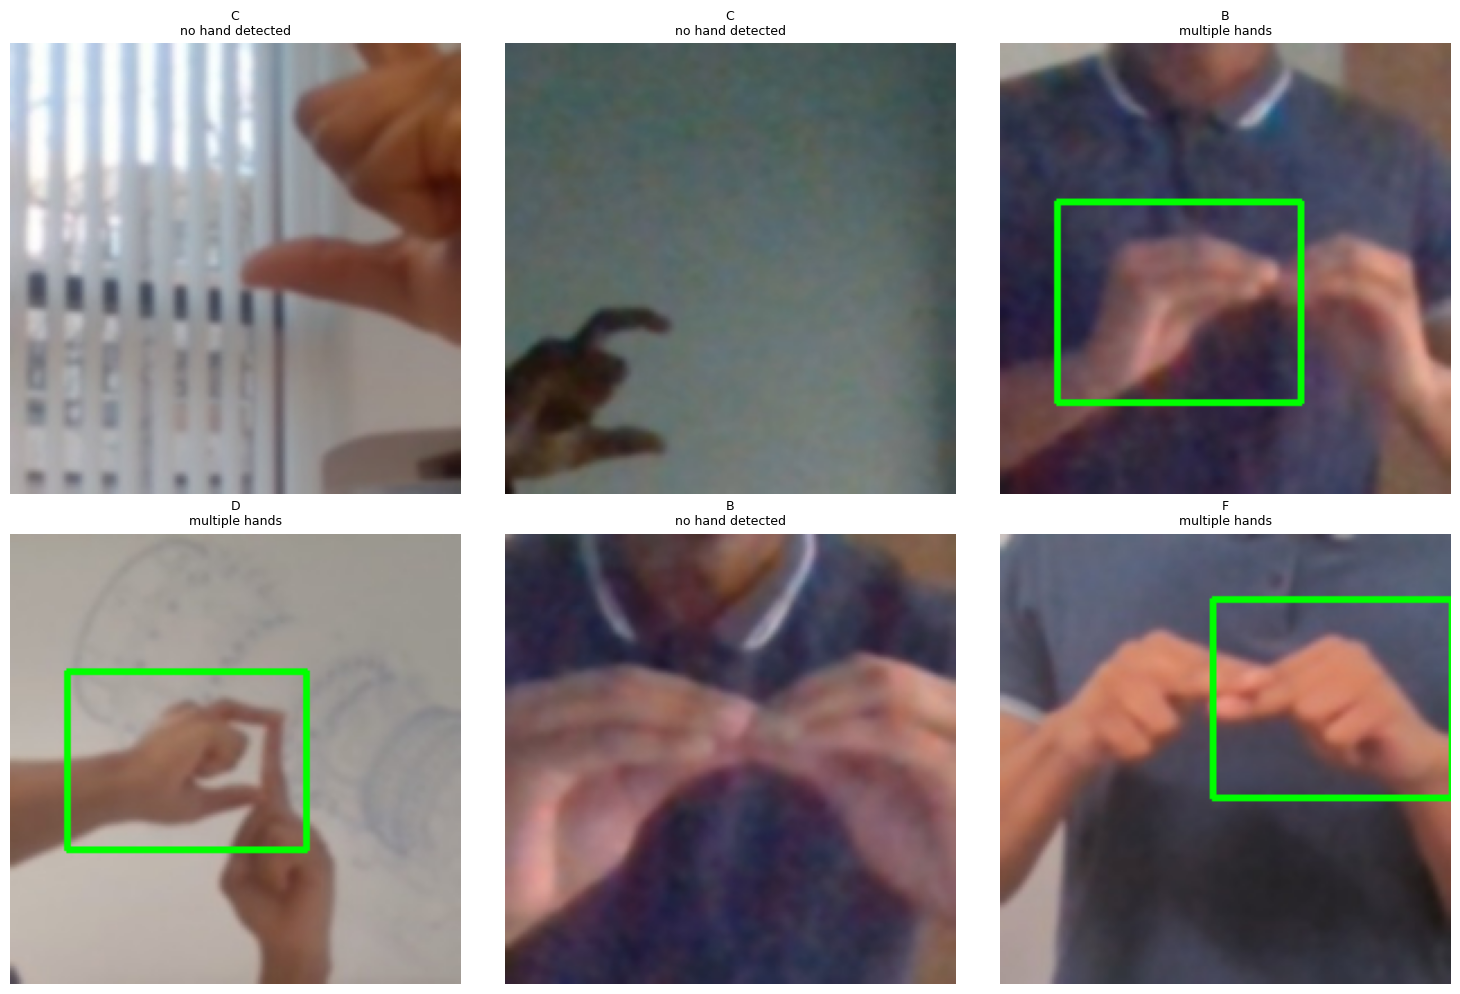

Saved: results/flagged_images_review.png


In [21]:
def visualize_flagged(hand_df, max_samples=6):
    flagged = hand_df[hand_df["review_flag"] != ""]
    if len(flagged) == 0:
        print("No flagged images."); return
    samples = flagged.sample(n=min(max_samples, len(flagged)), random_state=SEED)
    ncols = 3; nrows = (len(samples) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
    axes = axes.flatten() if nrows > 1 else [axes]
    for idx, (_, row) in enumerate(samples.iterrows()):
        ax = axes[idx]
        img = cv2.imread(row["image_path"])
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if row["x_min"] != "":
                cv2.rectangle(img, (int(row["x_min"]), int(row["y_min"])),
                              (int(row["x_max"]), int(row["y_max"])), (0,255,0), 2)
            ax.imshow(img)
        ax.set_title(f"{row['label_name']}\n{row['review_flag'].replace('_', ' ')}", fontsize=9)
        ax.axis("off")
    for i in range(len(samples), len(axes)): axes[i].axis("off")
    plt.tight_layout()
    plt.savefig(DIRS["results"] / "flagged_images_review.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results/flagged_images_review.png")

visualize_flagged(hand_annotations_df)

## Section 10: Final Annotations

In [22]:
def create_final_annotations(ann_df, hand_df, output_path):
    merged = ann_df.merge(
        hand_df[["image_path", "hand_detected", "num_hands",
                  "x_min", "y_min", "x_max", "y_max",
                  "landmark_points", "crop_path", "review_flag"]],
        on="image_path", how="left",
    )
    def get_quality(row):
        flag = str(row.get("review_flag", ""))
        if "unreadable" in flag: return "rejected"
        if not row.get("hand_detected", False): return "no_hand_detected"
        if "too_small" in flag: return "poor_crop"
        if "multiple" in flag: return "multiple_hands"
        if row.get("hand_detected", False): return "good"
        return "pending"
    merged["quality_status"] = merged.apply(get_quality, axis=1)
    merged = merged.sort_values(["label_name", "image_path"]).reset_index(drop=True)
    merged.to_csv(output_path, index=False)
    print(f"Final annotations: {output_path} ({len(merged)} entries)")
    print("Quality distribution:")
    for s, c in merged["quality_status"].value_counts().items():
        print(f"  {s}: {c} ({100*c/len(merged):.1f}%)")
    return merged

final_ann_path = DIRS["annotations"] / "final_annotations.csv"
final_df = create_final_annotations(annotations_df, hand_annotations_df, final_ann_path)
print("\nPreview:")
print(final_df.head().to_string())

Final annotations: /content/BSL_Project/annotations/final_annotations.csv (20910 entries)
Quality distribution:
  good: 9048 (43.3%)
  no_hand_detected: 8488 (40.6%)
  multiple_hands: 3374 (16.1%)

Preview:
                                                                       image_path label_name  label_id  user_id split  quality_status notes  hand_detected  num_hands x_min y_min x_max y_max                                                                                                                                                                                                                                                                                                                                                                      landmark_points                                                                             crop_path     review_flag
0                       /kaggle/input/bsl-fingerspelling-dataset/test/A/A (2).JPG          A         0  unknown  test           

## Section 11: Dataset Splitting

Stratified split into train (75%), validation (12.5%), and test (12.5%). Prevents user leakage where possible.

In [23]:
def stratified_split(df, label_col="label_name", user_col="user_id",
                     train_r=0.75, val_r=0.125, test_r=0.125, seed=SEED):
    # CRITICAL FIX: Only keep rows where label_id is valid (>= 0)
    valid = df[(df["quality_status"].isin(["good", "no_hand_detected", "poor_crop", "multiple_hands"])) & (df["label_id"] >= 0)].copy()
    print(f"Splitting {len(valid)} valid images with correct labels...")

    has_user = valid[user_col].nunique() > 1 and "unknown" not in valid[user_col].values
    if has_user:
        user_lbl = valid.groupby(user_col)[label_col].agg(lambda x: Counter(x).most_common(1)[0][0])
        ulist = list(user_lbl.index)
        utrain, utest = train_test_split(ulist, test_size=(val_r + test_r), stratify=[user_lbl[u] for u in ulist], random_state=seed)
        uval, utest2 = train_test_split(utest, test_size=test_r / (val_r + test_r), stratify=[user_lbl[u] for u in utest], random_state=seed)
        train_df = valid[valid[user_col].isin(utrain)]
        val_df = valid[valid[user_col].isin(uval)]
        test_df = valid[valid[user_col].isin(utest2)]
    else:
        train_df, temp = train_test_split(valid, test_size=(val_r + test_r), stratify=valid[label_col], random_state=seed)
        val_df, test_df = train_test_split(temp, test_size=test_r / (val_r + test_r), stratify=temp[label_col], random_state=seed)

    train_df = train_df.copy(); val_df = val_df.copy(); test_df = test_df.copy()
    train_df["split"] = "train"; val_df["split"] = "val"; test_df["split"] = "test"

    result = df.copy()
    result["split"] = "excluded" # Default everything to excluded
    for sdf in [train_df, val_df, test_df]:
        mask = result["image_path"].isin(sdf["image_path"])
        result.loc[mask, "split"] = sdf["split"].iloc[0]

    print(f"\nSplit complete (Valid Classes Only):")
    for name, sdf in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        print(f"  {name}: {len(sdf)} images")
    return result, train_df, val_df, test_df

final_df, train_df, val_df, test_df = stratified_split(final_df)
final_df.to_csv(final_ann_path, index=False)

Splitting 20742 valid images with correct labels...

Split complete (Valid Classes Only):
  Train: 15556 images
  Val: 2593 images
  Test: 2593 images


## Section 12: Organize Processed Dataset

In [24]:
def organize_dataset(final_df, base_dir, use_crops=True):
    base = Path(base_dir); organized = 0; fallback = 0; missing = 0
    for split_name in ["train", "val", "test"]:
        sdf = final_df[final_df["split"] == split_name]
        if len(sdf) == 0: continue
        print(f"  Organizing {split_name} ({len(sdf)} images)...")
        for _, row in tqdm(sdf.iterrows(), total=len(sdf), desc=f"  {split_name}"):
            label = row["label_name"]
            sdir = base / split_name / label; sdir.mkdir(parents=True, exist_ok=True)
            src = None
            if use_crops and row.get("hand_detected") and row.get("crop_path"):
                cp = Path(row["crop_path"])
                if cp.exists(): src = cp
                else: src = Path(row["image_path"]) if Path(row["image_path"]).exists() else None; fallback += 1
            else:
                src = Path(row["image_path"]) if Path(row["image_path"]).exists() else None; fallback += 1
            if src is None: missing += 1; continue
            dest = sdir / src.name
            if not dest.exists(): shutil.copy2(str(src), str(dest))
            organized += 1
    print(f"\nOrganized: {organized}, Fallback: {fallback}, Missing: {missing}")
    for s in ["train", "val", "test"]:
        sp = base / s
        if sp.exists():
            nc = len([d for d in sp.iterdir() if d.is_dir()])
            ni = sum(len(list(d.iterdir())) for d in sp.iterdir() if d.is_dir())
            print(f"  {s}: {nc} classes, {ni} images")

print("Organizing dataset (using hand crops where available)...")
organize_dataset(final_df, DIRS["processed_data"], use_crops=True)

Organizing dataset (using hand crops where available)...
  Organizing train (15556 images)...


  train: 100%|██████████| 15556/15556 [00:11<00:00, 1340.79it/s]


  Organizing val (2593 images)...


  val: 100%|██████████| 2593/2593 [00:02<00:00, 1256.61it/s]


  Organizing test (2593 images)...


  test: 100%|██████████| 2593/2593 [00:02<00:00, 1258.02it/s]



Organized: 20742, Fallback: 8467, Missing: 0
  train: 24 classes, 29582 images
  val: 24 classes, 6082 images
  test: 24 classes, 6097 images


## Section 13: Preprocessing and Data Augmentation

In [25]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print("Train augmentation: rotation(10), color jitter, random crop, translation")
print("Note: Aggressive flipping NOT used (could change sign meaning)")

Image size: 224x224
Train augmentation: rotation(10), color jitter, random crop, translation
Note: Aggressive flipping NOT used (could change sign meaning)


## Section 14: Custom PyTorch Dataset

Memory-efficient dataset that loads images on-the-fly. Implements `__init__`, `__len__`, `__getitem__`.

In [29]:
class BSLSignDataset(Dataset):
    def __init__(self, annotations_file, split, transform=None, mode="auto"):
        self.df = pd.read_csv(annotations_file)
        self.df = self.df[self.df['split'] == split].reset_index(drop=True)
        self.transform = transform
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']

        # Use hand crop if available and requested
        if self.mode == "auto" and pd.notna(row['crop_path']) and os.path.exists(str(row['crop_path'])):
            img_path = row['crop_path']

        image = Image.open(img_path).convert("RGB")
        label = int(row['label_id'])

        if self.transform:
            image = self.transform(image)

        return image, label

print("Re-creating datasets and loaders...")
train_dataset = BSLSignDataset(final_ann_path, "train", train_transform, "auto")
val_dataset = BSLSignDataset(final_ann_path, "val", val_transform, "auto")
test_dataset = BSLSignDataset(final_ann_path, "test", val_transform, "auto")

# Define loader parameters here to avoid NameError
BATCH_SIZE = 32
NUM_WORKERS = 2
PIN_MEM = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEM, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEM)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEM)

print(f"Created loaders with BATCH_SIZE={BATCH_SIZE}")

Re-creating datasets and loaders...
Created loaders with BATCH_SIZE=32


## Section 15: PyTorch DataLoaders

In [30]:
BATCH_SIZE = 32; NUM_WORKERS = 2; PIN_MEM = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEM, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEM)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEM)

print(f"Batch size: {BATCH_SIZE}, Workers: {NUM_WORKERS}, Pin: {PIN_MEM}")
print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

imgs, lbls = next(iter(train_loader))
print(f"Sample batch: {imgs.shape}, labels: {lbls.shape}")
print(f"Tensor range: [{imgs.min():.3f}, {imgs.max():.3f}]")

Batch size: 32, Workers: 2, Pin: True
Train batches: 486, Val: 82, Test: 82
Sample batch: torch.Size([32, 3, 224, 224]), labels: torch.Size([32])
Tensor range: [-2.118, 2.483]


## Section 16: CNN Model Creation (Transfer Learning)

Default: EfficientNet-B0 pretrained on ImageNet. Alternatives: MobileNetV3-Small, ResNet-18.

In [31]:
from efficientnet_pytorch import EfficientNet

# Ensure NUM_CLASSES strictly matches the current classes list
NUM_CLASSES = len(classes)
print(f"Initializing models for {NUM_CLASSES} classes: {classes}")

def create_efficientnet_b0(num_classes, pretrained=True):
    # Using EfficientNet-B0 as the primary architecture
    model = EfficientNet.from_pretrained("efficientnet-b0" if pretrained else None,
                                         num_classes=num_classes)
    return model

def create_mobilenet_v3(num_classes, pretrained=True):
    w = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretrained else None
    m = models.mobilenet_v3_small(weights=w)
    m.classifier = nn.Sequential(
        nn.Linear(576, 256), nn.Hardswish(inplace=True),
        nn.Dropout(p=0.2), nn.Linear(256, num_classes))
    return m

def create_resnet18(num_classes, pretrained=True):
    w = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    m = models.resnet18(weights=w)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

print("Creating EfficientNet-B0...")
try:
    # Move model to device
    model = create_efficientnet_b0(NUM_CLASSES, pretrained=True).to(device)

    total_p = sum(p.numel() for p in model.parameters())
    train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {total_p:,} total, {train_p:,} trainable")
    print(f"Model size: ~{total_p * 4 / (1024**2):.1f} MB")
    print(f"Alternatives available: create_mobilenet_v3, create_resnet18")
except Exception as e:
    print(f"Error initializing model: {e}")
    print("Tip: If a CUDA error persists, try 'Runtime -> Restart session' to clear the corrupted GPU state.")

Initializing models for 7 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Creating EfficientNet-B0...
Loaded pretrained weights for efficientnet-b0
Parameters: 4,016,515 total, 4,016,515 trainable
Model size: ~15.3 MB
Alternatives available: create_mobilenet_v3, create_resnet18


## Section 17: Training Configuration

In [32]:
def compute_class_weights(dataset):
    # Extract all labels from the dataset
    labels = [dataset.df.iloc[i]["label_id"] for i in range(len(dataset))]
    counts = Counter(labels)
    total = len(labels)

    # We must ensure weights are provided for every class index up to the max detected
    # to prevent indexing errors in the loss function.
    n_cls = max(counts.keys()) + 1 if counts else 0

    weights = []
    for c in range(n_cls):
        count = counts.get(c, 0)
        if count > 0:
            # Inverse frequency: total / (number_of_classes * class_count)
            weights.append(total / (n_cls * count))
        else:
            # Placeholder for missing classes to maintain tensor shape
            weights.append(1.0)

    return torch.tensor(weights, dtype=torch.float32).to(device)

try:
    class_weights = compute_class_weights(train_dataset)
    print(f"Class weights computed for {len(class_weights)} classes.")
except Exception as e:
    print(f"Error computing weights: {e}")
    print("TIP: If you see a 'CUDA error', please Restart Session (Runtime menu) and run again.")

Class weights computed for 7 classes.


In [33]:
CONFIG = {
    "epochs": 10,
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "patience": 5,
    "min_delta": 0.001,
    "confidence_threshold": 0.80,
    "smoothing_window": 10,
}

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"],
                         weight_decay=CONFIG["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6)

use_amp = torch.cuda.is_available()
scaler = GradScaler(enabled=use_amp)

print("Training config:")
for k, v in CONFIG.items(): print(f"  {k}: {v}")
print(f"Loss: CrossEntropyLoss (weighted)")
print(f"Optimizer: AdamW, Scheduler: ReduceLROnPlateau")
print(f"Mixed precision: {use_amp}")

Training config:
  epochs: 10
  learning_rate: 0.0003
  weight_decay: 0.0001
  patience: 5
  min_delta: 0.001
  confidence_threshold: 0.8
  smoothing_window: 10
Loss: CrossEntropyLoss (weighted)
Optimizer: AdamW, Scheduler: ReduceLROnPlateau
Mixed precision: True


## Section 18: Model Training

Training with validation, early stopping, best model saving, and mixed precision.

In [34]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler, use_amp):
    model.train()
    running_loss = 0.0; correct = 0; total = 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        if use_amp:
            with autocast():
                outputs = model(images); loss = criterion(outputs, labels)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            outputs = model(images); loss = criterion(outputs, labels)
            loss.backward(); optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, pred = outputs.max(1); total += labels.size(0)
        correct += pred.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0; correct = 0; total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images); loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, pred = outputs.max(1); total += labels.size(0)
            correct += pred.eq(labels).sum().item()
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return running_loss / total, 100.0 * correct / total, all_preds, all_labels

In [35]:
import torch
import gc

def train_model(model, train_ldr, val_ldr, crit, opt, sched, dev, cfg, use_amp):
    best_val = 0.0; best_state = None; patience_ctr = 0
    history = {"epoch": [], "train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": [], "lr": []}
    print(f"\nTraining for {cfg['epochs']} epochs (patience={cfg['patience']})...")
    print("=" * 60)
    t0 = time.time()

    if use_amp:
        from torch.cuda.amp import GradScaler
        scaler = GradScaler()
    else:
        scaler = None

    for epoch in range(1, cfg["epochs"] + 1):
        ep0 = time.time()

        if dev.type == 'cuda':
            torch.cuda.empty_cache()
            gc.collect()

        model.train()
        t_loss, t_acc = train_one_epoch(model, train_ldr, crit, opt, dev, scaler, use_amp)

        model.eval()
        with torch.no_grad():
            v_loss, v_acc, _, _ = validate(model, val_ldr, crit, dev)

        sched.step(v_acc)
        lr = opt.param_groups[0]["lr"]

        history["epoch"].append(epoch)
        history["train_loss"].append(t_loss); history["train_acc"].append(t_acc)
        history["val_loss"].append(v_loss); history["val_acc"].append(v_acc)
        history["lr"].append(lr)

        print(f"Epoch [{epoch:3d}/{cfg['epochs']}] Train: {t_loss:.4f}/{t_acc:.2f}% | Val: {v_loss:.4f}/{v_acc:.2f}% | LR: {lr:.2e} | {time.time()-ep0:.1f}s")

        if v_acc > best_val + cfg["min_delta"]:
            best_val = v_acc
            best_state = copy.deepcopy(model.state_dict())
            patience_ctr = 0
            torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": opt.state_dict(), "val_accuracy": v_acc, "config": cfg},
                       DIRS["models"] / "best_model.pth")
            print(f"  >> New best: {v_acc:.2f}%")
        else:
            patience_ctr += 1

        if patience_ctr >= cfg["patience"]:
            print(f"\nEarly stopping at epoch {epoch}. Best: {best_val:.2f}%")
            break

    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                "optimizer_state_dict": opt.state_dict(), "val_accuracy": v_acc,
                "config": cfg, "class_mapping": class_mapping, "reverse_mapping": reverse_mapping},
               DIRS["models"] / "final_model.pth")

    if best_state is not None:
        model.load_state_dict(best_state)

    pd.DataFrame(history).to_csv(DIRS["results"] / "training_history.csv", index=False)
    print(f"\nTraining done in {time.time()-t0:.1f}s. Best val acc: {best_val:.2f}%")

    if dev.type == 'cuda':
        torch.cuda.empty_cache()

    return model, history, best_val

# 1. Determine actual class count and validate labels
actual_num_classes = train_df['label_id'].max() + 1
print(f"Adjusting for {actual_num_classes} detected classes...")

# CRITICAL: Verify all labels are within range [0, actual_num_classes - 1]
if train_df['label_id'].min() < 0 or train_df['label_id'].max() >= actual_num_classes:
    raise ValueError(f"Labels in train_df are out of bounds: {train_df['label_id'].min()} to {train_df['label_id'].max()}")

# 2. Re-initialize model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

model = create_efficientnet_b0(actual_num_classes, pretrained=True).to(device)

# 3. Re-initialize optimizer/scheduler
optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6)

# 4. Re-compute weights and criterion
class_weights = compute_class_weights(train_dataset)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 5. Start training
try:
    model, training_history, best_val_acc = train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler, device, CONFIG, use_amp)
except RuntimeError as e:
    print(f"An error occurred during training: {e}")
    torch.cuda.empty_cache()
    gc.collect()

Adjusting for 7 detected classes...
Loaded pretrained weights for efficientnet-b0

Training for 10 epochs (patience=5)...


Epoch [  1/10] Train: 0.1327/96.77% | Val: 0.0037/99.88% | LR: 3.00e-04 | 133.0s
  >> New best: 99.88%


Epoch [  2/10] Train: 0.0148/99.61% | Val: 0.0078/99.81% | LR: 3.00e-04 | 118.8s


Epoch [  3/10] Train: 0.0077/99.76% | Val: 0.0036/99.88% | LR: 3.00e-04 | 117.0s


Epoch [  4/10] Train: 0.0044/99.91% | Val: 0.0051/99.88% | LR: 3.00e-04 | 117.4s


...

Epoch [  6/10] Train: 0.0032/99.90% | Val: 0.0007/100.00% | LR: 1.50e-04 | 118.8s
  >> New best: 100.00%


Epoch [  7/10] Train: 0.0015/99.95% | Val: 0.0003/100.00% | LR: 1.50e-04 | 115.4s


Epoch [  8/10] Train: 0.0036/99.90% | Val: 0.0003/100.00% | LR: 1.50e-04 | 116.0s


Epoch [  9/10] Train: 0.0016/99.93% | Val: 0.0009/99.96% | LR: 1.50e-04 | 115.1s


Epoch [ 10/10] Train: 0.0007/99.97% | Val: 0.0003/100.00% | LR: 7.50e-05 | 114.5s

Training done in 1187.1s. Best val acc: 100.00%


## Section 19: Training Curves

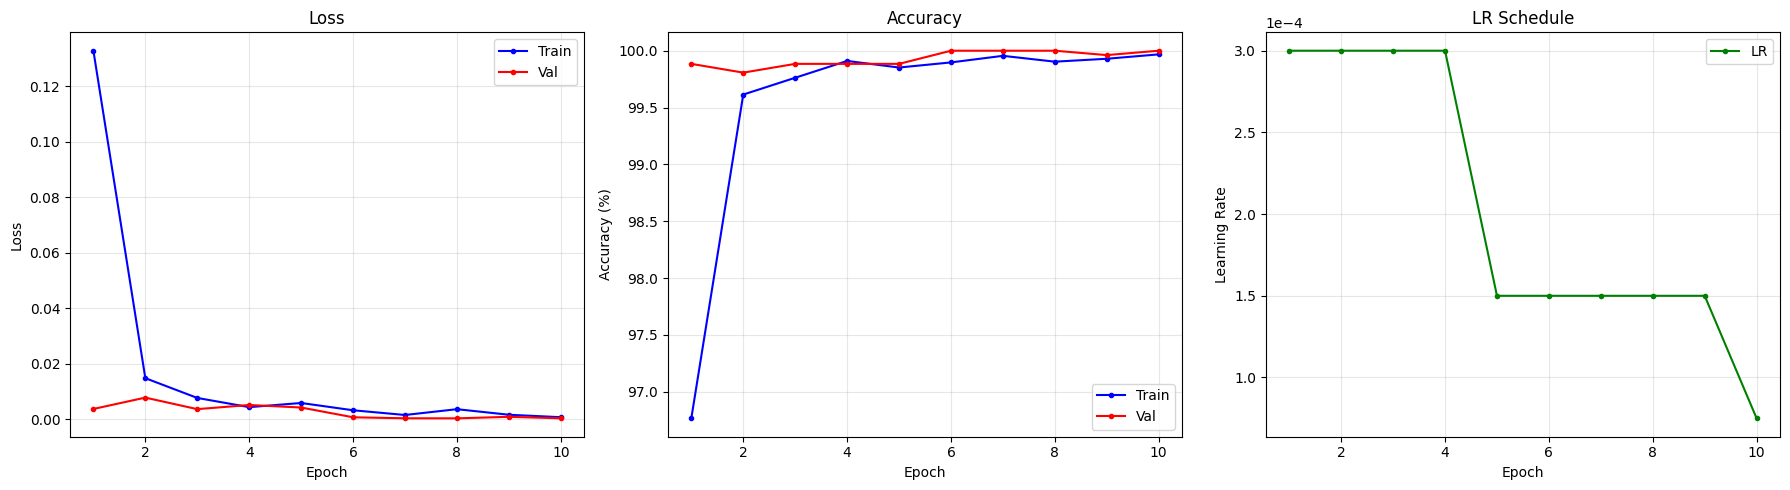

Saved: /content/BSL_Project/results/training_curves.png


In [36]:
def plot_training_curves(hist, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(hist["epoch"], hist["train_loss"], "b-o", label="Train", markersize=3)
    axes[0].plot(hist["epoch"], hist["val_loss"], "r-o", label="Val", markersize=3)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss"); axes[0].legend(loc="best"); axes[0].grid(True, alpha=0.3)

    axes[1].plot(hist["epoch"], hist["train_acc"], "b-o", label="Train", markersize=3)
    axes[1].plot(hist["epoch"], hist["val_acc"], "r-o", label="Val", markersize=3)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title("Accuracy"); axes[1].legend(loc="best"); axes[1].grid(True, alpha=0.3)

    axes[2].plot(hist["epoch"], hist["lr"], "g-o", label="LR", markersize=3)
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning Rate")
    axes[2].set_title("LR Schedule"); axes[2].legend(loc="best"); axes[2].grid(True, alpha=0.3)
    axes[2].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: {save_path}")

plot_training_curves(training_history, DIRS["results"] / "training_curves.png")

## Section 20: Model Evaluation

In [37]:
# Load best model
ckpt = torch.load(DIRS["models"] / "best_model.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best model from epoch {ckpt['epoch']} (val_acc={ckpt['val_accuracy']:.2f}%)")

test_loss, test_acc, all_preds, all_labels = validate(model, test_loader, criterion, device)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

Loaded best model from epoch 6 (val_acc=100.00%)



Test Loss: 0.0003, Test Accuracy: 100.00%


In [38]:
target_names = [reverse_mapping[i] for i in range(len(reverse_mapping))]
present = sorted(set(all_labels))
present_names = [target_names[i] for i in present]

report = classification_report(all_labels, all_preds, labels=present,
                               target_names=present_names, digits=4, output_dict=True)

report_path = DIRS["results"] / "classification_report.txt"
with open(report_path, "w") as f:
    f.write("BSL SIGN RECOGNITION - CLASSIFICATION REPORT\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Model: EfficientNet-B0 | Test Accuracy: {test_acc:.2f}%\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    f.write(classification_report(all_labels, all_preds, labels=present,
                                  target_names=present_names, digits=4))

print(classification_report(all_labels, all_preds, labels=present,
                            target_names=present_names, digits=4))
print(f"Report saved: {report_path}")

overall_acc = report["accuracy"]
macro_f1 = report["macro avg"]["f1-score"]
print(f"\nAccuracy: {overall_acc:.4f}, Macro F1: {macro_f1:.4f}")

              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000       376
           B     1.0000    1.0000    1.0000       376
           C     1.0000    1.0000    1.0000       377
           D     1.0000    1.0000    1.0000       377
           E     1.0000    1.0000    1.0000       377
           F     1.0000    1.0000    1.0000       334
           G     1.0000    1.0000    1.0000       376

    accuracy                         1.0000      2593
   macro avg     1.0000    1.0000    1.0000      2593
weighted avg     1.0000    1.0000    1.0000      2593

Report saved: /content/BSL_Project/results/classification_report.txt

Accuracy: 1.0000, Macro F1: 1.0000


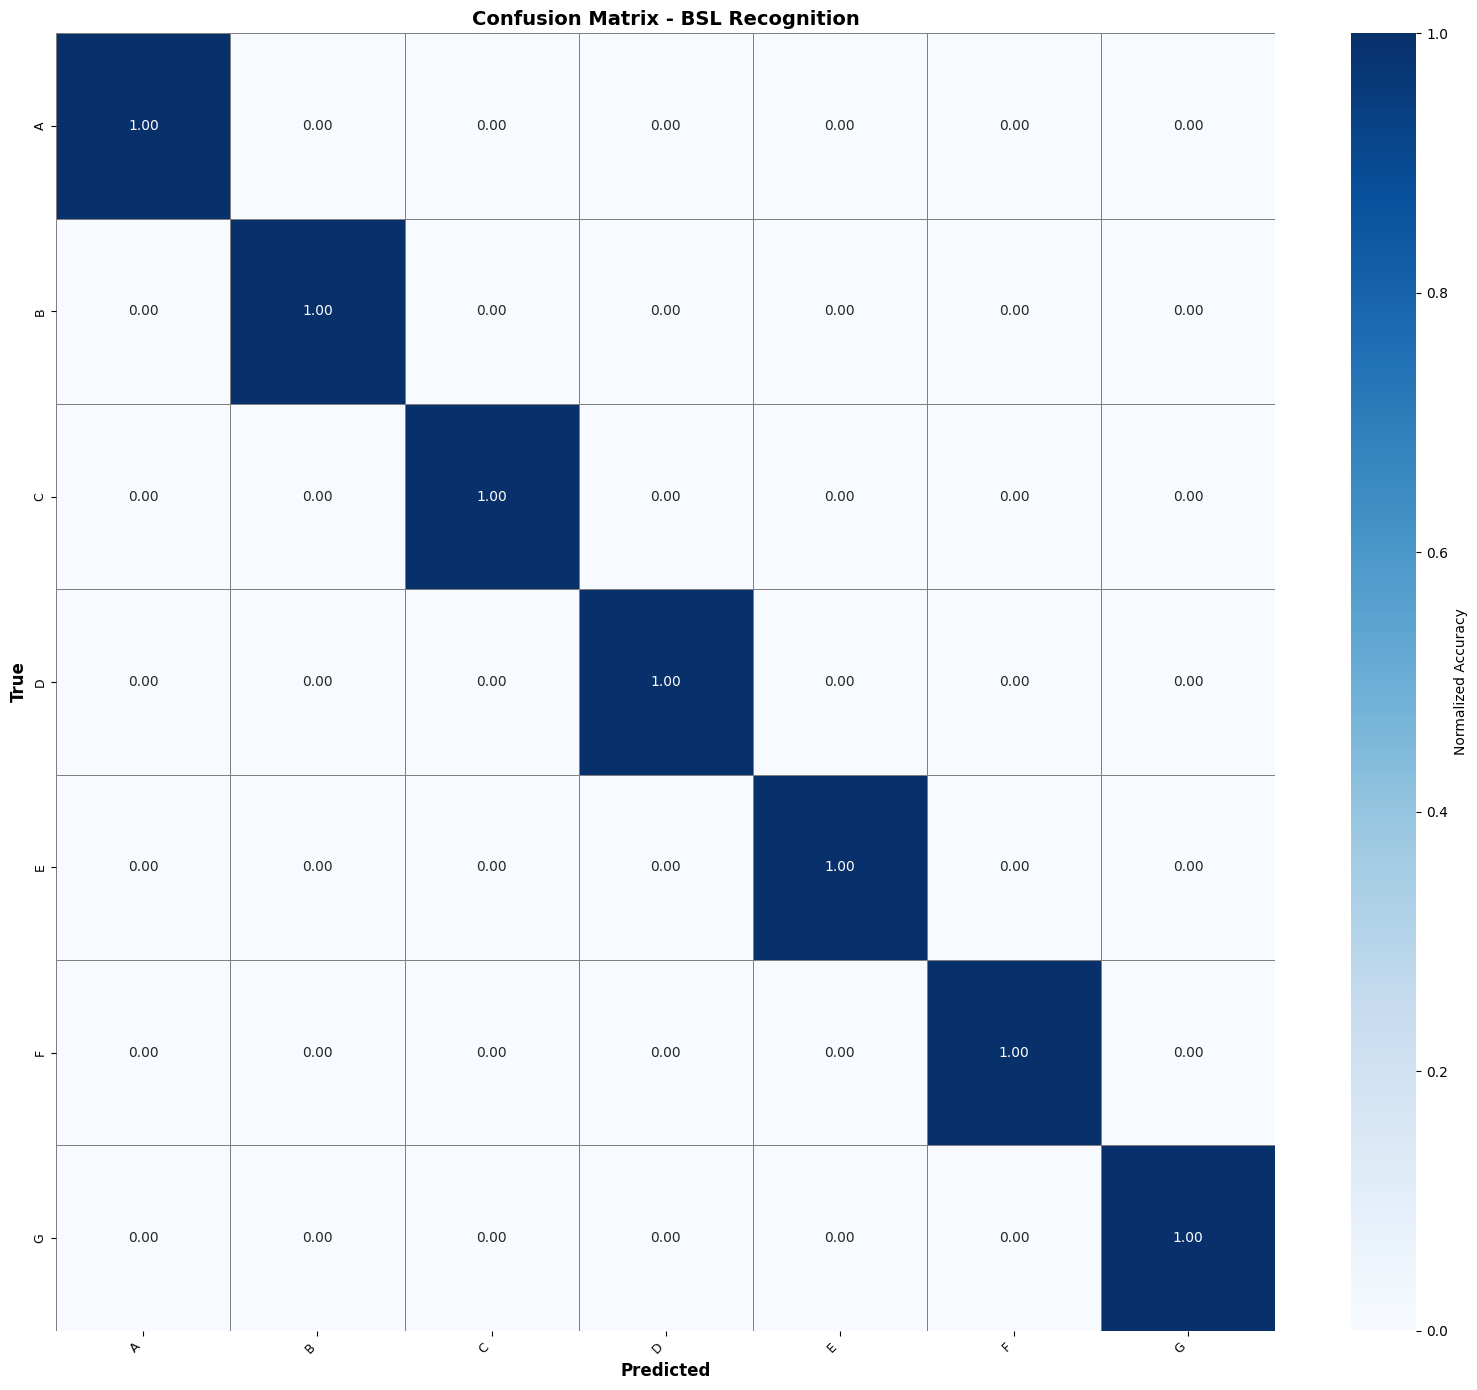

Saved: /content/BSL_Project/results/confusion_matrix.png


In [39]:
def plot_confusion_matrix(true, pred, names, save_path):
    cm = confusion_matrix(true, pred, labels=range(len(names)))
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=names, yticklabels=names, ax=ax,
                cbar_kws={"label": "Normalized Accuracy"},
                linewidths=0.5, linecolor="gray")
    ax.set_xlabel("Predicted", fontsize=12, fontweight="bold")
    ax.set_ylabel("True", fontsize=12, fontweight="bold")
    ax.set_title("Confusion Matrix - BSL Recognition", fontsize=14, fontweight="bold")
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: {save_path}")
    return cm

conf_matrix = plot_confusion_matrix(all_labels, all_preds, target_names,
                                    DIRS["results"] / "confusion_matrix.png")

In [40]:
# Per-class accuracy
per_class = {}
for cid in present:
    mask = np.array(all_labels) == cid
    correct = (np.array(all_preds)[mask] == cid).sum()
    total = mask.sum()
    per_class[target_names[cid]] = {"accuracy": correct / total if total else 0,
                                     "correct": int(correct), "total": int(total)}
sorted_acc = sorted(per_class.items(), key=lambda x: x[1]["accuracy"], reverse=True)
print("Per-class accuracy (sorted):")
print(f"  {'Class':<6} {'Acc':>8} {'Correct':>8} {'Total':>8}")
print("  " + "-" * 34)
for name, s in sorted_acc:
    print(f"  {name:<6} {s['accuracy']:>8.2%} {s['correct']:>8} {s['total']:>8}")
print(f"\nBest: {sorted_acc[0][0]} ({sorted_acc[0][1]['accuracy']:.2%})")
print(f"Worst: {sorted_acc[-1][0]} ({sorted_acc[-1][1]['accuracy']:.2%})")

Per-class accuracy (sorted):
  Class       Acc  Correct    Total
  ----------------------------------
  A       100.00%      376      376
  B       100.00%      376      376
  C       100.00%      377      377
  D       100.00%      377      377
  E       100.00%      377      377
  F       100.00%      334      334
  G       100.00%      376      376

Best: A (100.00%)
Worst: G (100.00%)


## Section 21: Test Predictions Export

In [41]:
def save_test_predictions(model, loader, dev, rmap, save_path):
    model.eval(); results = []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Predicting"):
            imgs = imgs.to(dev)
            out = model(imgs); prob = torch.softmax(out, dim=1)
            conf, pred = prob.max(dim=1)
            for i in range(imgs.size(0)):
                results.append({"label_id": int(lbls[i]), "predicted_id": int(pred[i]),
                                "confidence": float(conf[i]),
                                "label_name": rmap[int(lbls[i])],
                                "predicted_name": rmap[int(pred[i])],
                                "correct": int(lbls[i]) == int(pred[i])})
    df = pd.DataFrame(results); df.to_csv(save_path, index=False)
    print(f"Predictions saved: {save_path} ({df['correct'].mean():.2%} accuracy)")
    return df

# Note: Using reverse_mapping here to correctly translate numeric IDs to names
pred_df = save_test_predictions(model, test_loader, device, reverse_mapping,
                                DIRS["results"] / "test_predictions.csv")

Predicting: 100%|██████████| 82/82 [00:07<00:00, 11.53it/s]

Predictions saved: /content/BSL_Project/results/test_predictions.csv (100.00% accuracy)


## Section 22: Misclassification Analysis

In [42]:
def analyze_misclassifications(dataset, model, dev, rmap, save_path):
    model.eval(); misclassified = []
    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc="Checking"):
            img, lbl = dataset[idx]
            out = model(img.unsqueeze(0).to(dev))
            prob = torch.softmax(out, dim=1); conf, pred = prob.max(dim=1)
            if pred.item() != lbl:
                row = dataset.df.iloc[idx]
                misclassified.append({"image_path": row.get("image_path", ""),
                                      "crop_path": row.get("crop_path", ""),
                                      "true_label": rmap[lbl],
                                      "predicted_label": rmap[pred.item()],
                                      "confidence": round(conf.item(), 4), "notes": ""})
    df = pd.DataFrame(misclassified); df.to_csv(save_path, index=False)
    print(f"Misclassified: {len(df)}")
    if len(df) > 0:
        print(f"Avg confidence on errors: {df['confidence'].mean():.4f}")
        pairs = df.groupby(["true_label", "predicted_label"]).size().sort_values(ascending=False)
        print("\nMost common confusions:")
        for (t, p), c in pairs.head(10).items():
            print(f"  {t} -> {p}: {c}")
    return df

misclf_df = analyze_misclassifications(test_dataset, model, device, reverse_mapping,
                                       DIRS["results"] / "misclassified_samples.csv")

Checking: 100%|██████████| 2593/2593 [00:38<00:00, 67.63it/s]

Misclassified: 0


In [43]:
def visualize_misclassified(dataset, misclf_df, cmap, max_s=12):
    if len(misclf_df) == 0: print("No misclassified samples!"); return
    ncols = 4; samples = misclf_df.sample(n=min(max_s, len(misclf_df)), random_state=SEED)
    nrows = (len(samples) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))

    # Ensure axes is a flat array even if it's a single axis
    if nrows * ncols == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    for idx, (_, r) in enumerate(samples.iterrows()):
        ax = axes[idx]
        p = Path(r["crop_path"]) if r.get("crop_path") and Path(r["crop_path"]).exists() else Path(r["image_path"])
        if p.exists():
            ax.imshow(Image.open(p).convert("RGB"))
        ax.set_title(f"True: {r['true_label']} | Pred: {r['predicted_label']}\nConf: {r['confidence']:.2%}",
                     fontsize=9, color="red", fontweight="bold")
        ax.axis("off")

    for i in range(len(samples), len(axes)):
        axes[i].axis("off")

    plt.suptitle("Misclassified Samples", fontsize=14, fontweight="bold", color="red")
    plt.tight_layout()
    plt.savefig(DIRS["results"] / "misclassified_samples.png", dpi=150, bbox_inches="tight")
    plt.show()

visualize_misclassified(test_dataset, misclf_df, class_mapping)

No misclassified samples!


## Section 23: Real-Time Webcam Inference

Pipeline: Webcam frame > MediaPipe hand detection > Hand crop > Resize 224x224 > Normalize > Model prediction > Confidence threshold (0.80) > Prediction smoothing (majority vote, last 10 frames) > Display

In [44]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from collections import Counter

# Reuse the model path from Section 8
model_path = 'hand_landmarker.task'

# Initialize the Tasks HandLandmarker for live stream mode
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.7,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)
webcam_hands_detector = vision.HandLandmarker.create_from_options(options)

CONF_THRESH = CONFIG["confidence_threshold"]
SMOOTH_WIN = CONFIG["smoothing_window"]

def preprocess_for_model(img_bgr):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(rgb)
    t = val_transform(pil)
    return t.unsqueeze(0)

def smooth_prediction(label, conf, buf, win=SMOOTH_WIN):
    buf.append(label if conf >= CONF_THRESH else "uncertain")
    if len(buf) > win: buf.pop(0)
    return Counter(buf).most_common(1)[0][0]

In [45]:
def run_realtime_inference(model, cmap, rmap, dev, cam_idx=0):
    print("Starting real-time BSL recognition... Press q to quit")
    cap = cv2.VideoCapture(cam_idx)
    if not cap.isOpened():
        print("Cannot open webcam."); return None
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    model.eval(); buf = []; t0 = time.time(); fc = 0; inf_times = []

    while True:
        ret, frame = cap.read()
        if not ret: break
        fc += 1; frame_start = time.time()
        frame = cv2.flip(frame, 1)  # Mirror
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Convert to MediaPipe Image for Tasks API
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        # Using detection for video mode requires a timestamp
        timestamp_ms = int((time.time() - t0) * 1000)
        res = webcam_hands_detector.detect_for_video(mp_image, timestamp_ms)

        pred_text = "No hand detected"; conf = 0.0; color = (0, 0, 255)
        if res.hand_landmarks:
            hl = res.hand_landmarks[0]; h, w = frame.shape[:2]
            xc = [lm.x*w for lm in hl]; yc = [lm.y*h for lm in hl]
            x1 = max(0, int(min(xc))-20); y1 = max(0, int(min(yc))-20)
            x2 = min(w, int(max(xc))+20); y2 = min(h, int(max(yc))+20)
            crop = frame[y1:y2, x1:x2]
            if crop.size > 0:
                inp = preprocess_for_model(crop).to(dev)
                with torch.no_grad():
                    out = model(inp); prob = torch.softmax(out, dim=1)
                    c, p = prob.max(dim=1)
                conf = c.item(); raw = rmap[p.item()]
                smoothed = smooth_prediction(raw, conf, buf, SMOOTH_WIN)
                pred_text = "Uncertain" if smoothed == "uncertain" else smoothed
                color = (0, 255, 0) if pred_text != "Uncertain" else (0, 165, 255)
                inf_times.append(time.time() - frame_start)
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        fps = fc / (time.time() - t0)
        display = f"BSL: {pred_text}" + (f" ({conf:.1%})" if pred_text not in ["No hand detected", "Uncertain"] else "")
        cv2.rectangle(frame, (10, 10), (380, 80), (0, 0, 0), -1)
        cv2.putText(frame, display, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        cv2.putText(frame, f"FPS: {fps:.1f}", (20, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

        # In Colab, cv2.imshow won't work normally; users typically use output.clear and display(Image)
        # But we keep this for local/standard Jupyter compatibility
        try:
            cv2.imshow("BSL Sign Recognition", frame)
            if cv2.waitKey(1) & 0xFF == ord("q"): break
        except Exception:
            # Fallback for headless environments if necessary
            break

    cap.release(); cv2.destroyAllWindows()
    avg_fps = fc / (time.time() - t0) if fc else 0
    avg_inf = np.mean(inf_times) * 1000 if inf_times else 0
    perf = {"average_fps": round(avg_fps, 2), "avg_inference_ms": round(avg_inf, 2),
            "total_frames": fc, "duration_s": round(time.time()-t0, 2)}
    print(f"\nSession ended. FPS: {avg_fps:.1f}, Inference: {avg_inf:.2f}ms")
    return perf

print("Webcam inference (Tasks API) ready.")

Webcam inference (Tasks API) ready.


## Section 24: Real-Time Performance Recording

In [46]:
perf_path = DIRS["results"] / "realtime_performance.txt"
template = f"""Real-Time BSL Recognition Performance
========================================
Date: {datetime.now().strftime("%Y-%m-%d")}
Tester: [Fill in]
GPU: {gpu_name if torch.cuda.is_available() else "CPU only"}

--- Metrics ---
Frames Per Second: [Fill in]
Average Inference (ms): [Fill in]
Confidence Threshold: {CONF_THRESH}
Smoothing Window: {SMOOTH_WIN}

--- Conditions ---
Lighting: [Bright/Dim/Outdoor]
Background: [Plain/Cluttered]
Hand Position: [Center/Off-center]

--- Feedback ---
Ease of Use (1-10):
Recognition Speed (1-10):
Accuracy Impression (1-10):
Notes: [Free text]
"""
with open(perf_path, "w") as f: f.write(template)
print(f"Performance template saved: {perf_path}")

Performance template saved: /content/BSL_Project/results/realtime_performance.txt


## Section 25: User Testing Protocol

In [47]:
ut_path = DIRS["results"] / "user_testing_protocol.txt"
ut = f"""BSL User Testing Protocol
==============================

Session ID: [Auto]
Date: {datetime.now().strftime("%Y-%m-%d")}
User: user_test_[N]
BSL Experience: [None/Beginner/Intermediate/Fluent]

--- Environment ---
Lighting: [Bright/Dim/Outdoor]
Background: [Plain/Cluttered]
Camera: [Fill in]

--- Test Results ---
Sign | Correct | Predicted | Confidence | Notes
-----|---------|-----------|------------|------
A    |         |           |            |
B    |         |           |            |
[... continue for all 26 letters ...]
Z    |         |           |            |

--- Summary ---
Total: 26
Correct: [N]
Accuracy: [N/26]
Most Confused: [List]

--- Feedback ---
Q1: Ease of use (1-10):
Q2: Speed (1-10):
Q3: Accuracy impression (1-10):
Q4: Would you use daily? (Y/N):
Q5: Suggestions:
"""
with open(ut_path, "w") as f: f.write(ut)
print(f"User testing template: {ut_path}")

User testing template: /content/BSL_Project/results/user_testing_protocol.txt


## Section 26: Limitations

In [48]:
lim_path = DIRS["results"] / "limitations.txt"
limitations = [
    "LIMITATIONS OF BSL SIGN RECOGNITION PROTOTYPE (v1.0)",
    "=" * 60,
    "",
    "1. ISOLATED SIGN RECOGNITION ONLY",
    "   Recognises isolated static BSL signs from single images.",
    "   Does NOT perform continuous sign language recognition or",
    "   translate BSL grammar. Real BSL involves sequential gestures,",
    "   co-articulation, and grammatical structures differing from English.",
    "",
    "2. LIMITED VOCABULARY",
    "   Only BSL fingerspelling alphabet (A-Z). Does NOT recognise",
    "   BSL numbers, common words, greeting signs, or two-hand signs.",
    "",
    "3. STATIC IMAGE CONSTRAINTS",
    "   Trained on static images, not video. Signs relying on motion",
    "   (YES, NO, HELLO) cannot be reliably recognised.",
    "",
    "4. NO FACIAL EXPRESSION / BODY POSTURE ANALYSIS",
    "   BSL grammar relies heavily on facial expressions, mouth patterns,",
    "   head tilt, shoulder position. None of these are captured.",
    "",
    "5. LIGHTING AND ENVIRONMENT DEPENDENCY",
    "   Degrades in poor lighting, cluttered backgrounds may interfere,",
    "   assumes single clearly visible hand.",
    "",
    "6. CAMERA QUALITY DEPENDENCY",
    "   Low-resolution cameras produce blurry crops. Different cameras",
    "   may produce different colour profiles affecting detection.",
    "",
    "7. HAND VISIBILITY REQUIREMENTS",
    "   Hand must be fully visible. Partial occlusion (gloves, sleeves)",
    "   may fail. Skin tone representation in training data matters.",
    "",
    "8. CONFUSION BETWEEN SIMILAR SIGNS",
    "   Some BSL letters look similar (U/V, M/N, D and G/I).",
    "",
    "9. LIMITED GENERALISATION",
    "   May not generalise to unseen users, signing speeds, hand sizes,",
    "   personal variations, or regional BSL variations.",
    "",
    "10. NO SENTENCE-LEVEL CONTEXT",
    "    No understanding of context or BSL sentence construction.",
    "",
    "11. REAL-TIME PERFORMANCE LIMITATIONS",
    "    FPS depends on GPU. Latency may be unacceptable for fluid",
    "    conversation. MediaPipe adds computational overhead.",
    "",
    "12. SAFETY CONCERNS",
    "    NOT for sole communication. Research prototype only.",
    "    Incorrect translations could cause misunderstandings.",
]
with open(lim_path, "w") as f: f.write("\n".join(limitations))
print(f"Limitations saved: {lim_path}")
for line in limitations[:20]: print(line)

Limitations saved: /content/BSL_Project/results/limitations.txt
LIMITATIONS OF BSL SIGN RECOGNITION PROTOTYPE (v1.0)

1. ISOLATED SIGN RECOGNITION ONLY
   Recognises isolated static BSL signs from single images.
   Does NOT perform continuous sign language recognition or
   translate BSL grammar. Real BSL involves sequential gestures,
   co-articulation, and grammatical structures differing from English.

2. LIMITED VOCABULARY
   Only BSL fingerspelling alphabet (A-Z). Does NOT recognise
   BSL numbers, common words, greeting signs, or two-hand signs.

3. STATIC IMAGE CONSTRAINTS
   Trained on static images, not video. Signs relying on motion
   (YES, NO, HELLO) cannot be reliably recognised.

4. NO FACIAL EXPRESSION / BODY POSTURE ANALYSIS
   BSL grammar relies heavily on facial expressions, mouth patterns,
   head tilt, shoulder position. None of these are captured.


## Section 27: Future Improvement Plan

In [49]:
fut_path = DIRS["results"] / "future_improvement_plan.txt"
future = [
    "FUTURE IMPROVEMENT PLAN",
    "=" * 50,
    "",
    "PHASE 1: DATA (1-3 months)",
    "- Add BSL numbers, greetings, common words (target: 50-100 signs)",
    "- Collect from 50+ users with varied demographics",
    "- Multiple lighting, background, and camera conditions",
    "- Record video clips (2-5s) for dynamic signs",
    "",
    "PHASE 2: MODEL (3-6 months)",
    "- CNN-LSTM for spatial + temporal features",
    "- 3D CNN for spatiotemporal pattern recognition",
    "- Vision Transformers for video understanding",
    "- Facial expression recognition (MediaPipe Face Mesh)",
    "- Head pose and body posture tracking",
    "- Advanced augmentation: CutMix, MixUp, GAN synthetic data",
    "- Model optimization: distillation, quantization, NAS",
    "",
    "PHASE 3: SYSTEM (3-6 months)",
    "- Continuous sign recognition with sliding window",
    "- Sign segmentation and boundary detection",
    "- Context-aware recognition with language model",
    "- Text-to-speech output integration",
    "",
    "PHASE 4: DEPLOYMENT (6-12 months)",
    "- Web app: FastAPI backend + React frontend",
    "- Mobile app: React Native / Flutter + TFLite",
    "- On-device inference for offline use",
    "- Cloud auto-scaling and monitoring",
    "- A/B testing framework",
    "",
    "PHASE 5: RESEARCH (ongoing)",
    "- User studies with deaf BSL community",
    "- Bias audit across demographics",
    "- Privacy protection for video data",
    "- Publish at CVPR/ICCV/ECCV",
    "- Open-source dataset and models",
]
with open(fut_path, "w") as f: f.write("\n".join(future))
print(f"Future plan saved: {fut_path}")
for line in future: print(line)

Future plan saved: /content/BSL_Project/results/future_improvement_plan.txt
FUTURE IMPROVEMENT PLAN

PHASE 1: DATA (1-3 months)
- Add BSL numbers, greetings, common words (target: 50-100 signs)
- Collect from 50+ users with varied demographics
- Multiple lighting, background, and camera conditions
- Record video clips (2-5s) for dynamic signs

PHASE 2: MODEL (3-6 months)
- CNN-LSTM for spatial + temporal features
- 3D CNN for spatiotemporal pattern recognition
- Vision Transformers for video understanding
- Facial expression recognition (MediaPipe Face Mesh)
- Head pose and body posture tracking
- Advanced augmentation: CutMix, MixUp, GAN synthetic data
- Model optimization: distillation, quantization, NAS

PHASE 3: SYSTEM (3-6 months)
- Continuous sign recognition with sliding window
- Sign segmentation and boundary detection
- Context-aware recognition with language model
- Text-to-speech output integration

PHASE 4: DEPLOYMENT (6-12 months)
- Web app: FastAPI backend + React fronten

## Section 28: Project Summary

In [50]:
print("=" * 60)
print("PROJECT DELIVERABLES")
print("=" * 60)

deliverables = {
    "Annotations": [
        "annotations.csv", "class_mapping.json", "final_annotations.csv",
        "hand_annotations.csv", "validation_log.csv", "review_report.csv",
    ],
    "Models": ["best_model.pth", "final_model.pth"],
    "Results": [
        "training_history.csv", "training_curves.png",
        "classification_report.txt", "confusion_matrix.png",
        "test_predictions.csv", "misclassified_samples.csv",
        "misclassified_samples.png", "flagged_images_review.png",
        "realtime_performance.txt", "user_testing_protocol.txt",
        "limitations.txt", "future_improvement_plan.txt",
    ],
}

for cat, items in deliverables.items():
    print(f"\n{cat}:")
    for item in items:
        if cat == "Annotations":
            p = DIRS["annotations"] / item
        elif cat == "Models":
            p = DIRS["models"] / item
        else:
            p = DIRS["results"] / item
        exists = "OK" if p.exists() else "PENDING"
        print(f"  [{exists}] {p}")

print(f"\nModel: EfficientNet-B0")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Best Val Acc: {best_val_acc:.2f}%, Test Acc: {test_acc:.2f}%, Macro F1: {macro_f1:.4f}")

PROJECT DELIVERABLES

Annotations:
  [OK] /content/BSL_Project/annotations/annotations.csv
  [OK] /content/BSL_Project/annotations/class_mapping.json
  [OK] /content/BSL_Project/annotations/final_annotations.csv
  [OK] /content/BSL_Project/annotations/hand_annotations.csv
  [OK] /content/BSL_Project/annotations/validation_log.csv
  [OK] /content/BSL_Project/annotations/review_report.csv

Models:
  [OK] /content/BSL_Project/models/best_model.pth
  [OK] /content/BSL_Project/models/final_model.pth

Results:
  [OK] /content/BSL_Project/results/training_history.csv
  [OK] /content/BSL_Project/results/training_curves.png
  [OK] /content/BSL_Project/results/classification_report.txt
  [OK] /content/BSL_Project/results/confusion_matrix.png
  [OK] /content/BSL_Project/results/test_predictions.csv
  [OK] /content/BSL_Project/results/misclassified_samples.csv
  [PENDING] /content/BSL_Project/results/misclassified_samples.png
  [OK] /content/BSL_Project/results/flagged_images_review.png
  [OK] /co

In [51]:
import zipfile

def zip_dir(directory, output_zip):
    d = Path(directory)
    with zipfile.ZipFile(output_zip, "w", zipfile.ZIP_DEFLATED) as z:
        for f in d.rglob("*"):
            if f.is_file():
                z.write(f, f.relative_to(d.parent))
    sz = Path(output_zip).stat().st_size / (1024*1024)
    print(f"  Zipped: {output_zip} ({sz:.1f} MB)")

print("Zipping results for download...")
zip_dir(DIRS["results"], PROJECT_ROOT / "BSL_Results.zip")
zip_dir(DIRS["models"], PROJECT_ROOT / "BSL_Models.zip")
zip_dir(DIRS["annotations"], PROJECT_ROOT / "BSL_Annotations.zip")

print("\nDone! All deliverables generated.")

Zipping results for download...
  Zipped: /content/BSL_Project/BSL_Results.zip (0.5 MB)
  Zipped: /content/BSL_Project/BSL_Models.zip (85.5 MB)
  Zipped: /content/BSL_Project/BSL_Annotations.zip (3.5 MB)

Done! All deliverables generated.


## Section 29: Quick Start Guide

### Prerequisites:
1. Kaggle account with API token
2. Google Colab with GPU (Runtime > Change runtime type > T4 GPU)

### Steps:
1. Run Section 1: Setup
2. Section 3: Upload kaggle.json, download dataset
3. Sections 4-12: Process data
4. Sections 13-18: Train model (~20-40 min on T4)
5. Sections 19-22: Evaluate
6. Section 23: Real-time inference (needs webcam)

### Troubleshooting:
- **OOM**: Reduce batch_size to 16 or 8
- **Slow training**: Verify GPU with `torch.cuda.is_available()`
- **Kaggle fails**: Check API credentials